# 03 · UFC growth, geography and composition

Research question: how did event volume, participation and geographic representation change? Counts describe the supplied cohort, not a independently certified event census. The final year is incomplete.

In [1]:
from pathlib import Path
import sys
import io
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'raw').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data_loader import load_raw, profile_sources, verify_raw, TABLES
from src.pipeline import prepare
from src.analysis import *
from src.visualization import *
def show(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format='png', bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(figure)

## Prepare cohort

Restrict headlines to 1994–2026 UFC event scope.

In [2]:
data = prepare(save=False)
fights, appearances = cohort(data)
print(f"Cohort: {len(fights):,} fights, {fights.event_id.nunique():,} events, {appearances.fighter_id.nunique():,} fighters")
print(f"Date range: {fights.event_date.min():%Y-%m-%d} to {fights.event_date.max():%Y-%m-%d}")

Cohort: 8,820 fights, 783 events, 2,735 fighters
Date range: 1994-03-11 to 2026-08-08


## Scale and participation

Compare full calendar years; the hollow marker denotes the incomplete final year.

,fight_year,fights,events,finish_rate,ko_rate,submission_rate,decision_rate,title_rate,duration_minutes,stats_coverage,active_fighters,women_bout_share,divisions,known_location_events,countries_or_territories,international_event_share,events_growth_pct,partial_year,fights_per_event
0,1994,31,3,1.000000,0.354839,0.645161,0.000000,0.096774,3.675269,0.935484,37,0.000000,2,3,1,0.000000,NaN,False,10.333333
1,1995,40,4,0.875000,0.375000,0.500000,0.075000,0.175000,6.121250,0.850000,38,0.000000,2,4,1,0.000000,33.333333,False,10.0
2,1996,43,5,0.883721,0.627907,0.255814,0.116279,0.116279,5.689922,0.837209,40,0.000000,2,5,2,0.200000,25.000000,False,8.6
3,1997,41,5,0.780488,0.317073,0.463415,0.195122,0.268293,5.139431,0.951220,52,0.000000,4,5,2,0.200000,0.000000,False,8.2
4,1998,25,3,0.680000,0.360000,0.320000,0.320000,0.200000,9.449333,0.840000,38,0.000000,5,3,2,0.333333,-40.000000,False,8.333333
5,1999,44,6,0.750000,0.590909,0.159091,0.204545,0.136364,8.972348,1.000000,58,0.000000,6,6,2,0.166667,100.000000,False,7.333333
6,2000,43,6,0.581395,0.325581,0.255814,0.372093,0.139535,9.063178,1.000000,65,0.000000,6,6,2,0.333333,0.000000,False,7.166667
7,2001,40,5,0.650000,0.425000,0.225000,0.300000,0.250000,9.868750,1.000000,48,0.000000,5,5,1,0.000000,-16.666667,False,8.0
8,2002,53,7,0.698113,0.547170,0.150943,0.283019,0.169811,9.209434,1.000000,66,0.000000,5,7,2,0.142857,40.000000,False,7.571429
9,2003,41,5,0.634146,0.439024,0.195122,0.292683,0.170732,9.354065,1.000000,57,0.000000,5,5,1,0.000000,-28.571429,False,8.2


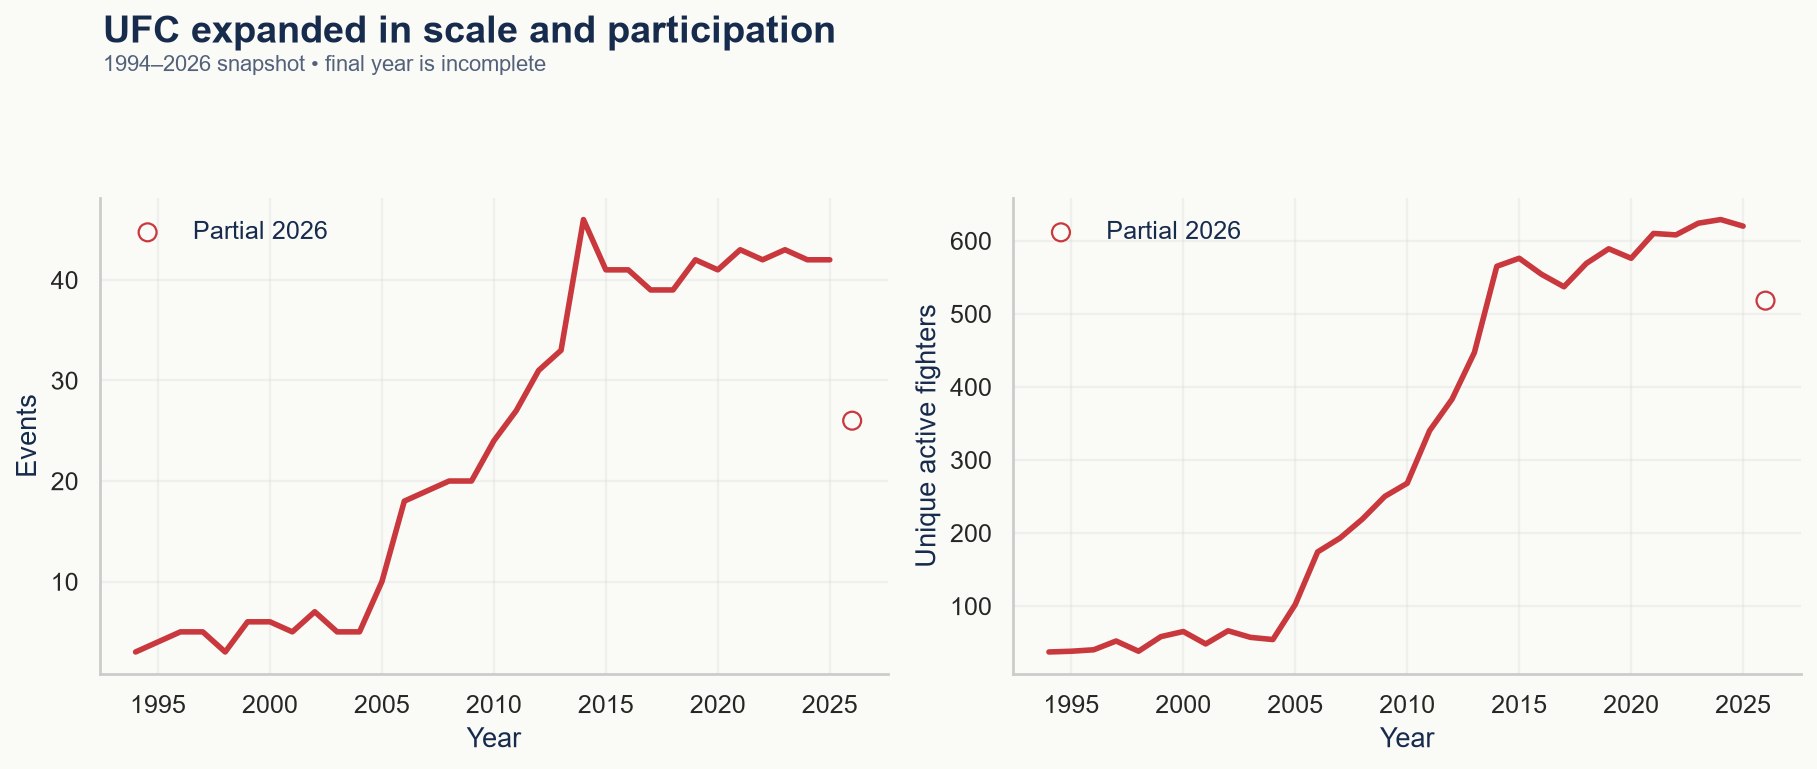

Events in 1994 / 2010 / 2025: {1994: 3, 2010: 24, 2025: 42}


In [3]:
annual = annual_summary(fights, appearances)
display(annual)
show(history_chart(fights, appearances))
print('Events in 1994 / 2010 / 2025:', annual.set_index('fight_year').loc[[1994,2010,2025],'events'].to_dict())

## International representation

Country is parsed from the final location segment. Source territory labels remain unchanged; missing locations are excluded from geographic rates.

In [4]:
events = event_summary(fights)
display(events.groupby('country',dropna=False).agg(events=('event_id','size'), first_year=('event_year','min')).sort_values('events',ascending=False))
display(annual.query('2018 <= fight_year <= 2025')[['fight_year','events','international_event_share','countries_or_territories']])

,events,first_year
country,,
USA,551,1994
Brazil,41,1998
Canada,37,2008
United Kingdom,31,2002
United Arab Emirates,23,2010
Australia,22,2010
China,9,2012
Mexico,9,2014
Japan,9,1997


,fight_year,events,international_event_share,countries_or_territories
24,2018,39,0.410256,11
25,2019,42,0.476190,15
26,2020,41,0.268293,4
27,2021,43,0.093023,2
28,2022,42,0.119048,5
29,2023,43,0.232558,8
30,2024,42,0.261905,10
31,2025,42,0.333333,12


## Cards and representation

Title indicators are observed; main-event status and venue names are unavailable. Women’s participation is inferred from division labels.

In [5]:
display(events.groupby('event_category').agg(events=('event_id','size'), mean_fights=('fights','mean'), mean_finish_rate=('finish_rate','mean')))
display(annual[['fight_year','women_bout_share','divisions','title_rate','fights_per_event']].tail(15))
display(events.nlargest(10,'fights')[['event_name','event_date','fights','finish_rate']])

,events,mean_fights,mean_finish_rate
event_category,,,
Numbered UFC,326,10.865031,0.552132
Other UFC card,429,11.62704,0.508049
TUF finale,28,10.357143,0.581942


,fight_year,women_bout_share,divisions,title_rate,fights_per_event
18,2012,0.000000,9,0.055718,11.0
19,2013,0.041451,9,0.059585,11.69697
20,2014,0.059642,11,0.051690,10.934783
21,2015,0.093023,11,0.054968,11.536585
22,2016,0.101420,12,0.050710,12.02439
23,2017,0.137856,13,0.045952,11.717949
24,2018,0.154008,12,0.044304,12.153846
25,2019,0.178295,13,0.036822,12.285714
26,2020,0.177632,13,0.039474,11.121951
27,2021,0.188605,13,0.039293,11.837209


,event_name,event_date,fights,finish_rate
45,UFC Fight Night: Aspinall vs. Tybura,2023-07-22,15,0.400000
280,UFC 283: Teixeira vs. Hill,2023-01-21,15,0.666667
345,UFC 259: Blachowicz vs. Adesanya,2021-03-06,15,0.533333
504,UFC 2: No Way Out,1994-03-11,15,1.000000
685,UFC Fight Night: Whittaker vs. Till,2020-07-25,15,0.400000
706,UFC 286: Edwards vs. Usman 3,2023-03-18,15,0.400000
6,UFC 304: Edwards vs. Muhammad 2,2024-07-27,14,0.357143
21,UFC Fight Night: Moicano vs. Saint Denis,2024-09-28,14,0.428571
24,UFC Fight Night: Joanna vs. Waterson,2019-10-12,14,0.428571
29,UFC 263: Adesanya vs. Vettori 2,2021-06-12,14,0.214286


## Era comparison

Calendar decades are transparent descriptive bins, not claims about exact rule or ownership changes. The first and last bins have incomplete calendar coverage.

,era,fights,years,finish_rate,ko_rate,submission_rate,decision_rate,duration_minutes,fights_per_observed_year,mean_sig_per_minute,mean_td_per_15,mean_age,mean_height_inches,mean_reach_inches
0,1993–1999,224,6,0.830357,0.450893,0.379464,0.147321,6.451711,37.333333,2.410465,3.180982,29.549767,72.418824,73.958333
1,2000–2009,1041,10,0.647454,0.391931,0.255524,0.338136,8.999920,104.1,2.855424,2.120762,28.762182,71.581172,73.549781
2,2010–2019,4196,10,0.496187,0.311964,0.184223,0.482364,10.835979,419.6,3.726534,1.532099,30.123218,70.187031,72.003394
3,2020–2026,3359,7,0.494492,0.319143,0.175350,0.484966,11.053821,479.857143,4.344267,1.467553,31.476621,69.803364,71.588717


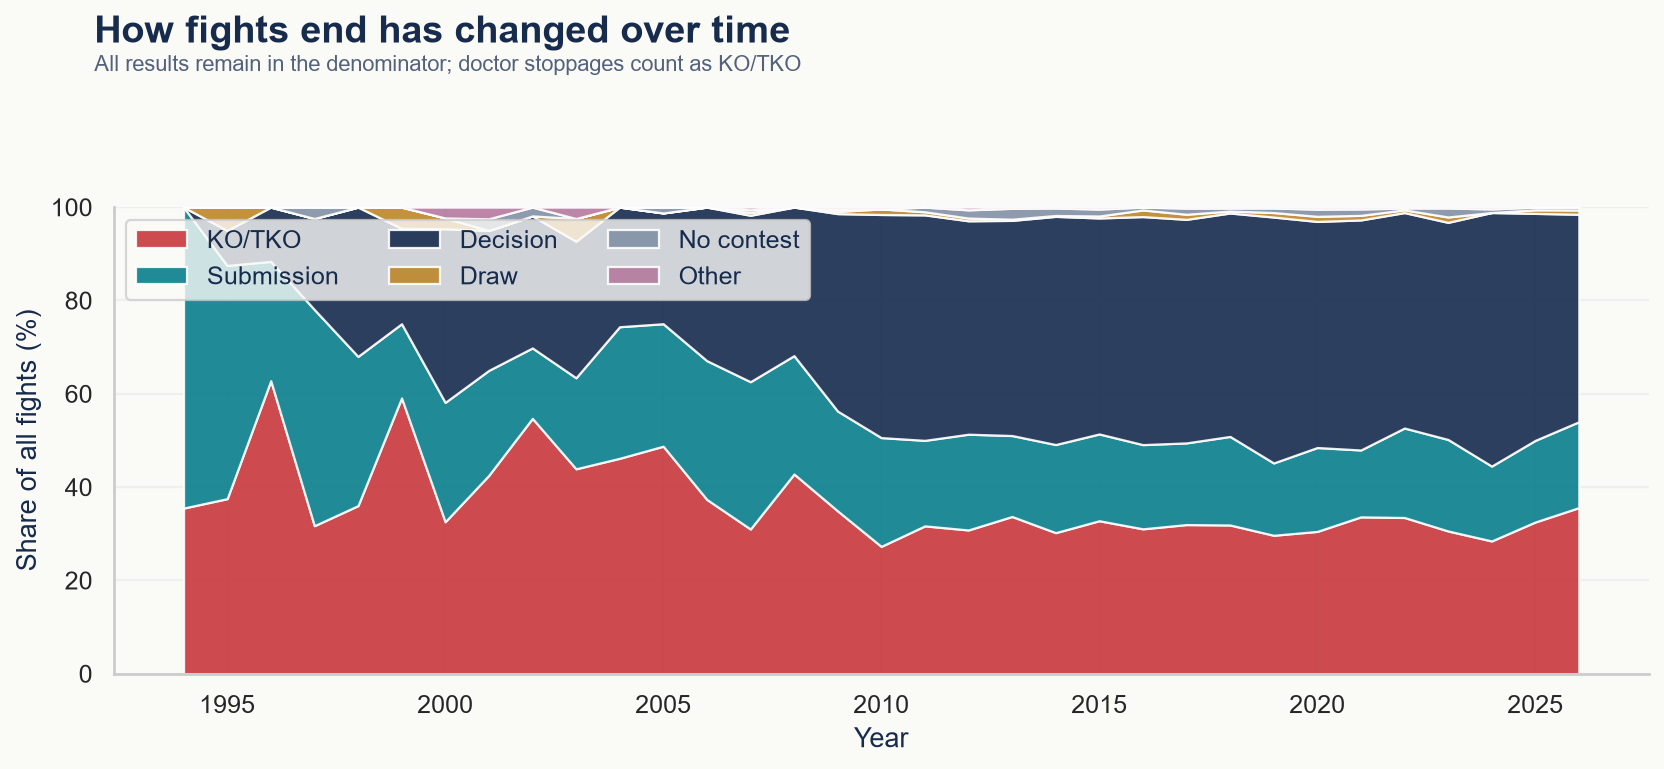

In [6]:
era_tables = export_outcomes(data)
display(era_tables['era_comparison'])
show(outcome_chart(fights))

## Research extension: What drives growth, geographic spread and fighter turnover?

The following answers are computed from the current snapshot. Tables expose denominators and missingness so the claims can be checked.

In [7]:
from src.research import run_chapter, display_answers
deep_tables, deep_answers = run_chapter('03')
display_answers(deep_answers)

### Did fight volume grow through more events or larger cards?

**Answer.** From 2010 to 2015, fight volume changed by 220; the exact decomposition attributes 187.7 fights to event count and 32.3 to card size.

**Interpretation.** This symmetric accounting identity divides the interaction equally. It explains arithmetic contributions, not causal drivers of the schedule.

### Does visiting more countries mean events are evenly distributed?

**Answer.** In 2025 the snapshot includes 12 country/territory labels, but concentration is equivalent to only 2.19 equally represented hosts.

**Interpretation.** The reciprocal Herfindahl index distinguishes geographic breadth from geographic balance. It weights events, not fighters or audience reach.

### How much of the active roster consists of new UFC entrants?

**Answer.** In 2025, 95 of 620 active fighters (15.3%) had their first observed UFC bout that year.

**Interpretation.** A first observed appearance is not necessarily a professional debut. Annual counts omit inactive athletes, so this is participation rather than roster size.

### How persistent is yearly fighter participation?

**Answer.** Among 629 fighters active in 2024, 475 (75.5%) also appear in 2025.

**Interpretation.** Not returning the next year does not prove release or retirement. Injury, inactivity and incomplete source coverage can produce the same pattern; partial 2026 is excluded.

In [8]:
display(deep_tables['deep_growth_decomposition'])

,start,end,fight_change,event_count_contribution,card_size_contribution,start_events,end_events,start_card_size,end_card_size
0,2005,2010,173,129.791667,43.208333,10,24,8.000000,10.541667
1,2010,2015,220,187.665142,32.334858,24,41,10.541667,11.536585
2,2015,2025,47,11.958769,35.041231,41,42,11.536585,12.380952


In [9]:
display(deep_tables['deep_geographic_concentration'])

,year,events,countries,country_hhi,effective_country_count,usa_share,largest_city_share
0,1994,3,1,1.000000,1.000000,1.000000,0.333333
1,1995,4,1,1.000000,1.000000,1.000000,0.250000
2,1996,5,2,0.680000,1.470588,0.800000,0.400000
3,1997,5,2,0.680000,1.470588,0.800000,0.200000
4,1998,3,2,0.555556,1.800000,0.666667,0.333333
5,1999,6,2,0.722222,1.384615,0.833333,0.166667
6,2000,6,2,0.555556,1.800000,0.666667,0.333333
7,2001,5,1,1.000000,1.000000,1.000000,0.400000
8,2002,7,2,0.755102,1.324324,0.857143,0.428571
9,2003,5,1,1.000000,1.000000,1.000000,0.400000


In [10]:
display(deep_tables['deep_entrant_flow'])

,fight_year,active_fighters,new_fighters,returning_fighters,entrant_share
0,1994,37,32,5,0.864865
1,1995,38,26,12,0.684211
2,1996,40,29,11,0.725
3,1997,52,38,14,0.730769
4,1998,38,30,8,0.789474
5,1999,58,35,23,0.603448
6,2000,65,39,26,0.6
7,2001,48,23,25,0.479167
8,2002,66,24,42,0.363636
9,2003,57,24,33,0.421053


In [11]:
display(deep_tables['deep_annual_return'])

,year,active,seen_next_year,next_year_return_share
0,2000,65,22,0.338462
1,2001,48,33,0.687500
2,2002,66,28,0.424242
3,2003,57,29,0.508772
4,2004,54,30,0.555556
5,2005,102,72,0.705882
6,2006,174,107,0.614943
7,2007,193,132,0.683938
8,2008,219,153,0.698630
9,2009,250,172,0.688000
